# StyleGAN2 — Entraînement

**Ce notebook fait deux choses :**
1. Entraîne StyleGAN2 sur FFHQ-256 (256×256)
2. Génère automatiquement `train.py` à la fin

L'environnement est **auto-détecté** :
- En local  → 100 images, 2 epochs (test rapide)
- Sur RunPod → 70 000 images, 200 epochs (production)

**Améliorations clés :**
- Résolution 256×256 (vs 64×64) — visages bien plus réalistes
- EMA Generator (Exponential Moving Average) — images plus nettes et stables
- Truncation trick disponible dans 02_visualize.ipynb

## 1 — Setup

In [1]:
import sys, os, torch

STYLEGAN2_DIR = os.path.abspath('.')
ROOT          = os.path.abspath('..')
for p in [STYLEGAN2_DIR, ROOT]:
    if p not in sys.path:
        sys.path.insert(0, p)

if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
    print(f'GPU : {torch.cuda.get_device_name(0)}')
    print(f'VRAM : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} Go')
else:
    device = torch.device('cpu')

import config as cfg
import importlib; importlib.reload(cfg)

os.makedirs(cfg.CHECKPOINTS_DIR,    exist_ok=True)
os.makedirs(cfg.GENERATED_IMGS_DIR, exist_ok=True)
os.makedirs(cfg.METRICS_DIR,        exist_ok=True)

print(f'Device     : {device}')
print(f'MODE       : {cfg.MODE}')
print(f'DATA_PATH  : {cfg.DATA_PATH}')
print(f'NUM_EPOCHS : {cfg.NUM_EPOCHS}')
print(f'BATCH_SIZE : {cfg.BATCH_SIZE}')

Device     : mps
MODE       : local
DATA_PATH  : /Users/Apple/Desktop/Projets/Deep learning/data/ffhq256_sample
NUM_EPOCHS : 10
BATCH_SIZE : 4


## 2 — Données

Images        : 100
Batches/epoch : 25


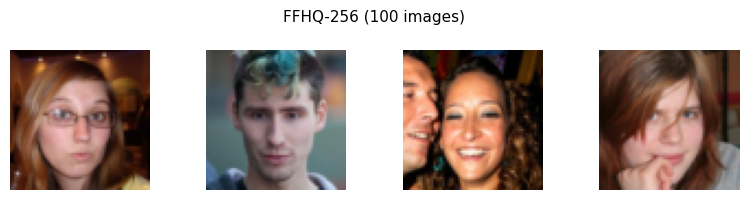

In [2]:
from torch.utils.data import DataLoader
from utils.loader import FFHQDataset
from utils.visualizer import show_grid

dataset    = FFHQDataset(cfg.DATA_PATH, cfg.IMG_SIZE)
dataloader = DataLoader(
    dataset,
    batch_size=cfg.BATCH_SIZE,
    shuffle=True,
    num_workers=cfg.NUM_WORKERS
)

print(f'Images        : {len(dataset)}')
print(f'Batches/epoch : {len(dataloader)}')

batch = next(iter(dataloader))
show_grid(batch, title=f'FFHQ-256 ({len(dataset)} images)')

## 3 — Modèle

In [ ]:
import copy
import torch.optim as optim
from model import build_stylegan2

G, D = build_stylegan2(cfg.Z_DIM, cfg.W_DIM, cfg.CHANNELS, device)

optimizer_G = optim.Adam(G.parameters(), lr=cfg.LR_G, betas=(cfg.BETA1, cfg.BETA2))
optimizer_D = optim.Adam(D.parameters(), lr=cfg.LR_D, betas=(cfg.BETA1, cfg.BETA2))

# EMA : copie de G dont les poids sont une moyenne exponentielle
# -> images plus nettes et stables que G seul
G_ema = copy.deepcopy(G)
G_ema.eval()
EMA_DECAY = 0.999

print(f'Paramètres G : {sum(p.numel() for p in G.parameters()):,}')
print(f'Paramètres D : {sum(p.numel() for p in D.parameters()):,}')

# Test forward
z = torch.randn(2, cfg.Z_DIM).to(device)
img = G(z)
print(f'Forward G : z{list(z.shape)} -> img{list(img.shape)}')
print('Modèle OK')

## 4 — R1 Regularization

Pénalise les gradients du discriminateur sur les vraies images.
Formule : `R1 = (gamma/2) * mean(||grad_D(real)||²)`

Empêche D de devenir trop confiant — stabilise l'entraînement.

In [4]:
import torch.nn.functional as F

def r1_regularization(D, real_imgs, gamma):
    real_imgs = real_imgs.detach().requires_grad_(True)
    real_score = D(real_imgs).sum()
    grad = torch.autograd.grad(
        outputs=real_score,
        inputs=real_imgs,
        create_graph=True
    )[0]
    return (gamma / 2) * grad.pow(2).sum([1, 2, 3]).mean()

print('R1 définie.')

R1 définie.


## 5 — Boucle d'entraînement

**À chaque batch :**
1. Entraîner D : vraies images vs fausses (Non-Saturating Loss)
2. R1 tous les `R1_EVERY` batches : stabiliser D
3. Entraîner G : tromper D
4. Mettre à jour G_ema : `ema = decay * ema + (1-decay) * G`
5. Collecter les vecteurs W pour l'analyse des attributs plus tard

**G_ema** est utilisé pour les snapshots — ses images sont plus nettes que G brut.

In [ ]:
from utils.visualizer import save_snapshot, plot_losses

z_fixed     = torch.randn(16, cfg.Z_DIM).to(device)
losses_G    = []
losses_D    = []
w_samples   = []   # vecteurs W collectés pour analyse attributs
batch_count = 0

print(f'Entraînement — {cfg.NUM_EPOCHS} epochs | {len(dataloader)} batches/epoch')
print('=' * 60)

for epoch in range(1, cfg.NUM_EPOCHS + 1):
    G.train(); D.train()
    sum_G = 0; sum_D = 0

    for real_imgs in dataloader:
        real_imgs = real_imgs.to(device)
        n         = real_imgs.size(0)
        batch_count += 1

        # ── Entraîner D ──
        optimizer_D.zero_grad()
        z         = torch.randn(n, cfg.Z_DIM).to(device)
        fake_imgs = G(z)

        loss_D = (
            F.softplus(-D(real_imgs)).mean() +
            F.softplus( D(fake_imgs.detach())).mean()
        )
        if batch_count % cfg.R1_EVERY == 0:
            loss_D = loss_D + r1_regularization(D, real_imgs.clone(), cfg.R1_GAMMA)

        loss_D.backward()
        optimizer_D.step()

        # ── Entraîner G ──
        optimizer_G.zero_grad()
        z         = torch.randn(n, cfg.Z_DIM).to(device)
        fake_imgs = G(z)
        loss_G    = F.softplus(-D(fake_imgs)).mean()
        loss_G.backward()
        optimizer_G.step()

        # ── Mise à jour EMA ──
        with torch.no_grad():
            for p_ema, p in zip(G_ema.parameters(), G.parameters()):
                p_ema.data.mul_(EMA_DECAY).add_(p.data, alpha=1 - EMA_DECAY)

        sum_G += loss_G.item()
        sum_D += loss_D.item()

        # Collecter vecteurs W tous les 10 batches
        if batch_count % 10 == 0:
            with torch.no_grad():
                w = G.mapping(z[:4])
                w_samples.append(w.cpu())

    avg_G = sum_G / len(dataloader)
    avg_D = sum_D / len(dataloader)
    losses_G.append(avg_G)
    losses_D.append(avg_D)

    if epoch % cfg.SAVE_EVERY == 0 or epoch == 1:
        save_snapshot(G_ema, z_fixed, epoch, cfg.GENERATED_IMGS_DIR, cfg.Z_DIM, device)
        print(f'Epoch [{epoch:3d}/{cfg.NUM_EPOCHS}] G={avg_G:.4f} D={avg_D:.4f} | snapshot (G_ema)')
    else:
        print(f'Epoch [{epoch:3d}/{cfg.NUM_EPOCHS}] G={avg_G:.4f} D={avg_D:.4f}')

print('=' * 60)
print('Entraînement terminé.')

## 6 — Sauvegarde du checkpoint

On sauvegarde **tout** ce dont on aura besoin pour l'API et l'analyse des attributs.

In [ ]:
# Courbes de loss
plot_losses(losses_G, losses_D, cfg.METRICS_DIR)

# Checkpoint complet
w_tensor  = torch.cat(w_samples, dim=0) if w_samples else torch.tensor([])
ckpt_path = os.path.join(cfg.CHECKPOINTS_DIR, 'stylegan2_final.pt')

torch.save({
    # Génération d'images (G_ema = version stable pour production)
    'G_state_dict'     : G.state_dict(),
    'G_ema_state_dict' : G_ema.state_dict(),
    'D_state_dict'     : D.state_dict(),
    # Reprise d'entraînement
    'optimizer_G'  : optimizer_G.state_dict(),
    'optimizer_D'  : optimizer_D.state_dict(),
    'epoch'        : cfg.NUM_EPOCHS,
    # Métriques
    'losses_G'     : losses_G,
    'losses_D'     : losses_D,
    # Analyse des attributs (âge, sourire, genre...)
    'w_samples'    : w_tensor,
    # Config pour reconstruire le modèle
    'config'       : {
        'z_dim'    : cfg.Z_DIM,
        'w_dim'    : cfg.W_DIM,
        'img_size' : cfg.IMG_SIZE,
        'mode'     : cfg.MODE,
    }
}, ckpt_path)

print(f'Checkpoint sauvegardé : {ckpt_path}')
print(f'Vecteurs W sauvegardés : {w_tensor.shape}')
print(f'G_ema inclus dans le checkpoint.')

## 7 — Export vers train.py

Cette cellule génère automatiquement `train.py` à partir du code du notebook.
Sur RunPod on pourra lancer directement `python train.py` sans ouvrir Jupyter.

In [ ]:
train_py = '''
import sys, os, copy, torch, torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader

sys.path.insert(0, os.path.dirname(os.path.dirname(os.path.abspath(__file__))))
sys.path.insert(0, os.path.dirname(os.path.abspath(__file__)))

import config as cfg
from model import build_stylegan2
from utils.loader import FFHQDataset
from utils.visualizer import save_snapshot, plot_losses


def r1_regularization(D, real_imgs, gamma):
    real_imgs = real_imgs.detach().requires_grad_(True)
    real_score = D(real_imgs).sum()
    grad = torch.autograd.grad(real_score, real_imgs, create_graph=True)[0]
    return (gamma / 2) * grad.pow(2).sum([1, 2, 3]).mean()


def train():
    if torch.backends.mps.is_available():
        device = torch.device("mps")
    elif torch.cuda.is_available():
        device = torch.device("cuda")
        print(f"GPU  : {torch.cuda.get_device_name(0)}")
        print(f"VRAM : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} Go")
    else:
        device = torch.device("cpu")

    print(f"MODE   : {cfg.MODE}")
    print(f"Device : {device}")

    os.makedirs(cfg.CHECKPOINTS_DIR,    exist_ok=True)
    os.makedirs(cfg.GENERATED_IMGS_DIR, exist_ok=True)
    os.makedirs(cfg.METRICS_DIR,        exist_ok=True)

    dataset    = FFHQDataset(cfg.DATA_PATH, cfg.IMG_SIZE)
    dataloader = DataLoader(dataset, batch_size=cfg.BATCH_SIZE,
                            shuffle=True, num_workers=cfg.NUM_WORKERS)
    print(f"Dataset : {len(dataset)} images | {len(dataloader)} batches/epoch")

    G, D = build_stylegan2(cfg.Z_DIM, cfg.W_DIM, cfg.CHANNELS, device)
    optimizer_G = optim.Adam(G.parameters(), lr=cfg.LR_G, betas=(cfg.BETA1, cfg.BETA2))
    optimizer_D = optim.Adam(D.parameters(), lr=cfg.LR_D, betas=(cfg.BETA1, cfg.BETA2))

    G_ema      = copy.deepcopy(G)
    G_ema.eval()
    EMA_DECAY  = 0.999

    z_fixed     = torch.randn(16, cfg.Z_DIM).to(device)
    losses_G    = []; losses_D = []; w_samples = []
    batch_count = 0

    print(f"Entrainement — {cfg.NUM_EPOCHS} epochs")
    print("-" * 55)

    for epoch in range(1, cfg.NUM_EPOCHS + 1):
        G.train(); D.train()
        sum_G = 0; sum_D = 0

        for real_imgs in dataloader:
            real_imgs = real_imgs.to(device)
            n = real_imgs.size(0)
            batch_count += 1

            optimizer_D.zero_grad()
            z = torch.randn(n, cfg.Z_DIM).to(device)
            fake_imgs = G(z)
            loss_D = (F.softplus(-D(real_imgs)).mean() +
                      F.softplus( D(fake_imgs.detach())).mean())
            if batch_count % cfg.R1_EVERY == 0:
                loss_D = loss_D + r1_regularization(D, real_imgs.clone(), cfg.R1_GAMMA)
            loss_D.backward()
            optimizer_D.step()

            optimizer_G.zero_grad()
            z = torch.randn(n, cfg.Z_DIM).to(device)
            fake_imgs = G(z)
            loss_G = F.softplus(-D(fake_imgs)).mean()
            loss_G.backward()
            optimizer_G.step()

            with torch.no_grad():
                for p_ema, p in zip(G_ema.parameters(), G.parameters()):
                    p_ema.data.mul_(EMA_DECAY).add_(p.data, alpha=1 - EMA_DECAY)

            sum_G += loss_G.item()
            sum_D += loss_D.item()

            if batch_count % 10 == 0:
                with torch.no_grad():
                    w = G.mapping(z[:4])
                    w_samples.append(w.cpu())

        avg_G = sum_G / len(dataloader)
        avg_D = sum_D / len(dataloader)
        losses_G.append(avg_G)
        losses_D.append(avg_D)

        if epoch % cfg.SAVE_EVERY == 0 or epoch == 1:
            save_snapshot(G_ema, z_fixed, epoch, cfg.GENERATED_IMGS_DIR, cfg.Z_DIM, device)
            w_tensor = torch.cat(w_samples, dim=0) if w_samples else torch.tensor([])
            ckpt = {
                "G_state_dict"     : G.state_dict(),
                "G_ema_state_dict" : G_ema.state_dict(),
                "D_state_dict"     : D.state_dict(),
                "optimizer_G"      : optimizer_G.state_dict(),
                "optimizer_D"      : optimizer_D.state_dict(),
                "epoch"            : epoch,
                "losses_G"         : losses_G,
                "losses_D"         : losses_D,
                "w_samples"        : w_tensor,
                "config"           : {"z_dim": cfg.Z_DIM, "w_dim": cfg.W_DIM,
                                      "img_size": cfg.IMG_SIZE, "mode": cfg.MODE},
            }
            torch.save(ckpt, os.path.join(cfg.CHECKPOINTS_DIR, f"stylegan2_ep{epoch:04d}.pt"))
            print(f"Epoch [{epoch:3d}/{cfg.NUM_EPOCHS}] G={avg_G:.4f} D={avg_D:.4f} | saved")
        else:
            print(f"Epoch [{epoch:3d}/{cfg.NUM_EPOCHS}] G={avg_G:.4f} D={avg_D:.4f}")

    plot_losses(losses_G, losses_D, cfg.METRICS_DIR)
    w_tensor = torch.cat(w_samples, dim=0) if w_samples else torch.tensor([])
    torch.save({
        "G_state_dict"     : G.state_dict(),
        "G_ema_state_dict" : G_ema.state_dict(),
        "D_state_dict"     : D.state_dict(),
        "epoch"            : cfg.NUM_EPOCHS,
        "losses_G"         : losses_G,
        "losses_D"         : losses_D,
        "w_samples"        : w_tensor,
        "config"           : {"z_dim": cfg.Z_DIM, "w_dim": cfg.W_DIM,
                              "img_size": cfg.IMG_SIZE, "mode": cfg.MODE},
    }, os.path.join(cfg.CHECKPOINTS_DIR, "stylegan2_final.pt"))
    print("-" * 55)
    print("Termine.")


if __name__ == "__main__":
    train()
'''

train_py_path = os.path.join(STYLEGAN2_DIR, 'train.py')
with open(train_py_path, 'w') as f:
    f.write(train_py.strip())

print(f'train.py généré : {train_py_path}')
print('Sur RunPod : python train.py')